# Event-Aware Uplift Modeling for Promotion Decisions in E-Commerce

### From Sequential Customer Behavior to Incremental Promotion Effect

**Objective**

This project develops an event-aware uplift modeling pipeline to estimate
whether a promotion is expected to generate additional purchase behavior
for individual customer-product decision points.

Unlike conventional purchase propensity modeling, the main target is the
incremental treatment effect:

\[
\tau(X) = E[Y(1)-Y(0)\mid X]
\]

The analysis uses real-world e-commerce event data over a five-month period.

In [ ]:
# ============================================================
# 1.1 INSTALL REQUIRED LIBRARIES
# ============================================================

%pip install -q kagglehub lightgbm shap tensorflow

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# ============================================================
# 1.2 IMPORT LIBRARIES
# ============================================================

import os
import warnings
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Optional libraries
try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("LightGBM unavailable.")

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("SHAP unavailable.")

try:
    import tensorflow as tf
    from tensorflow.keras import layers, Model
    HAS_TF = True
except ImportError:
    HAS_TF = False
    print("TensorFlow unavailable.")

# Reproducibility
SEED = 42

np.random.seed(SEED)
random.seed(SEED)

if HAS_TF:
    tf.random.set_seed(SEED)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# 2. Dataset Loading

The analysis uses the REES46 multi-category e-commerce event dataset.

Five monthly files are combined to construct a continuous observation period
from October 2019 to February 2020.

In [ ]:
# ============================================================
# 2.1 DOWNLOAD DATASET
# ============================================================

import kagglehub

path = kagglehub.dataset_download(
    "mkechinov/ecommerce-events-history-in-cosmetics-shop"
)

print("Dataset path:")
print(path)

Dataset path:
/Users/Vicky/.cache/kagglehub/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/versions/6


In [ ]:
# ============================================================
# 2.2 INSPECT AVAILABLE FILES
# ============================================================

available_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            available_files.append(
                os.path.join(root, file)
            )

for f in available_files:
    print(f)

/Users/Vicky/.cache/kagglehub/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/versions/6/2020-Jan.csv
/Users/Vicky/.cache/kagglehub/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/versions/6/2019-Dec.csv
/Users/Vicky/.cache/kagglehub/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/versions/6/2020-Feb.csv
/Users/Vicky/.cache/kagglehub/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/versions/6/2019-Nov.csv
/Users/Vicky/.cache/kagglehub/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/versions/6/2019-Oct.csv


In [ ]:
# ============================================================
# 2.3 LOAD FIVE MONTHS
# ============================================================

MONTHS = [
    "2019-Oct.csv",
    "2019-Nov.csv",
    "2019-Dec.csv",
    "2020-Jan.csv",
    "2020-Feb.csv"
]

USECOLS = [
    "event_time",
    "event_type",
    "product_id",
    "category_id",
    "category_code",
    "brand",
    "price",
    "user_id",
    "user_session"
]

DTYPES = {
    "event_type": "category",
    "product_id": "int32",
    "category_id": "float32",
    "category_code": "string",
    "brand": "string",
    "price": "float32",
    "user_id": "int64",
    "user_session": "string"
}

data_parts = []

for month in MONTHS:

    file_path = os.path.join(path, month)

    print(f"Loading {month}...")

    temp = pd.read_csv(
        file_path,
        usecols=USECOLS,
        dtype=DTYPES
    )

    data_parts.append(temp)

df = pd.concat(
    data_parts,
    ignore_index=True
)

df["event_time"] = pd.to_datetime(
    df["event_time"],
    errors="coerce"
)

df = (
    df
    .sort_values("event_time")
    .reset_index(drop=True)
)

print("\n==============================")
print("DATASET LOADED")
print("==============================")

print("Rows:", f"{len(df):,}")
print("Columns:", len(df.columns))
print("Start:", df["event_time"].min())
print("End:", df["event_time"].max())

display(df.head())

Loading 2019-Oct.csv...
Loading 2019-Nov.csv...
Loading 2019-Dec.csv...
Loading 2020-Jan.csv...
Loading 2020-Feb.csv...

DATASET LOADED
Rows: 20,692,840
Columns: 9
Start: 2019-10-01 00:00:00+00:00
End: 2020-02-29 23:59:59+00:00


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00+00:00,cart,5773203,1.487580e+18,<NA>,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
1,2019-10-01 00:00:03+00:00,cart,5773353,1.487580e+18,<NA>,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
2,2019-10-01 00:00:07+00:00,cart,5881589,2.151191e+18,<NA>,lovely,13.48,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9
3,2019-10-01 00:00:07+00:00,cart,5723490,1.487580e+18,<NA>,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
4,2019-10-01 00:00:15+00:00,cart,5881449,1.487580e+18,<NA>,lovely,0.56,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9


# 3. Data Understanding

Before preprocessing, the raw event log is inspected to verify:

- available variables
- event types
- missing values
- timestamp coverage
- user and product coverage

This step does not create causal labels or treatment variables.

In [ ]:
# ============================================================
# 3.1 BASIC INFORMATION
# ============================================================

print("=== SHAPE ===")
print(df.shape)

print("\n=== COLUMNS ===")
print(df.columns.tolist())

print("\n=== DATA TYPES ===")
print(df.dtypes)

=== SHAPE ===
(20692840, 9)

=== COLUMNS ===
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']

=== DATA TYPES ===
event_time       datetime64[us, UTC]
event_type                  category
product_id                     int32
category_id                  float32
category_code                 string
brand                         string
price                        float32
user_id                        int64
user_session                  string
dtype: object


In [ ]:
# ============================================================
# 3.2 MISSING VALUES
# ============================================================

missing = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing.to_frame("missing_count")
)

,missing_count
category_code,20339246
brand,8757117
user_session,4598
event_time,0
event_type,0
product_id,0
category_id,0
price,0
user_id,0


In [ ]:
# ============================================================
# 3.3 EVENT DISTRIBUTION
# ============================================================

event_counts = (
    df["event_type"]
    .value_counts()
)

display(
    event_counts.to_frame("count")
)

print(
    "Event types:",
    df["event_type"].unique()
)

,count
event_type,
view,9657821
cart,5768333
remove_from_cart,3979679
purchase,1287007


Event types: ['cart', 'view', 'remove_from_cart', 'purchase']
Categories (4, str): ['cart', 'purchase', 'remove_from_cart', 'view']


# 4. Configuration

All analytical parameters are centralized here.

Some parameters remain data-dependent and should be checked empirically
before the final model is locked, especially:

- treatment definition
- outcome window
- event-detection threshold
- sequence length
- uplift estimator

This follows the revised methodology.

In [ ]:
# ============================================================
# 4.1 CONFIGURATION
# ============================================================

CONFIG = {

    # Data
    "months": MONTHS,

    # Columns
    "time": "event_time",
    "event": "event_type",
    "user": "user_id",
    "session": "user_session",
    "product": "product_id",
    "category": "category_id",
    "brand": "brand",
    "price": "price",

    # Event definitions
    "decision_event": "cart",
    "purchase_event": "purchase",

    # Session
    "session_gap_minutes": 30,

    # Outcome
    "outcome_window_minutes": 120,

    # Event discovery
    "mad_z_threshold": 2.5,

    # Sequence
    "max_sequence_length": 4,

    # GRU
    "embedding_dim": 8,
    "gru_units": 16,

    # Validation
    "validation_ratio": 0.20,
    "test_ratio": 0.20,

    # Treatment
    # Starting threshold only — validate empirically
    "discount_threshold": 0.05,

    # Policy
    "tau_threshold": 0.05,

    # Seed
    "seed": 42
}

print("Configuration loaded.")

Configuration loaded.


# 5. Stage 1 — Real-Data Preprocessing

The raw event log is cleaned without creating artificial behavioral or
causal labels.

The preprocessing includes:

1. column normalization
2. duplicate removal
3. timestamp conversion
4. numeric conversion
5. missing-value handling
6. invalid price removal
7. chronological sorting

In [ ]:
# ============================================================
# 5.1 PREPROCESSING FUNCTION
# ============================================================

def preprocess_data(df):

    data = df.copy()

    # Normalize column names
    data.columns = (
        data.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

    # Timestamp
    data["event_time"] = pd.to_datetime(
        data["event_time"],
        errors="coerce"
    )

    # Numeric
    data["price"] = pd.to_numeric(
        data["price"],
        errors="coerce"
    )

    # Remove duplicates
    before_dup = len(data)

    data = data.drop_duplicates(
        subset=[
            "user_id",
            "product_id",
            "event_type",
            "event_time"
        ]
    )

    print(
        "Duplicates removed:",
        before_dup - len(data)
    )

    # Required fields
    before_missing = len(data)

    data = data.dropna(
        subset=[
            "event_time",
            "user_id",
            "product_id",
            "price"
        ]
    )

    print(
        "Missing required rows removed:",
        before_missing - len(data)
    )

    # Valid price
    before_price = len(data)

    data = data[
        data["price"] > 0
    ]

    print(
        "Invalid price rows removed:",
        before_price - len(data)
    )

    # Sort
    data = (
        data
        .sort_values(
            ["user_id", "event_time"]
        )
        .reset_index(drop=True)
    )

    return data

In [ ]:
# ============================================================
# 5.2 RUN PREPROCESSING
# ============================================================

df_clean = preprocess_data(df)

print("\nClean dataset:")
print(df_clean.shape)

display(df_clean.head())

Duplicates removed: 1120960
Missing required rows removed: 0
Invalid price rows removed: 82736

Clean dataset:
(19489144, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-01-14 16:15:21+00:00,view,5865526,1.487580e+18,<NA>,cnd,10.00,465496,8ad668e6-9567-4da9-b43b-250f12ecab5b
1,2020-01-14 16:25:35+00:00,view,5769989,1.487580e+18,<NA>,cnd,10.00,465496,d4b9b57f-237c-4427-80e1-b0073b0b0b6c
2,2020-01-14 16:27:31+00:00,view,5865524,1.487580e+18,<NA>,cnd,10.00,465496,d4b9b57f-237c-4427-80e1-b0073b0b0b6c
3,2019-11-04 15:28:57+00:00,view,5240,1.487580e+18,<NA>,runail,4.05,1120748,d0484d94-7ac1-44e8-a310-2360da11ad9d
4,2019-12-28 14:32:56+00:00,view,5881337,1.487580e+18,<NA>,fedua,25.40,1180452,a4818e6d-9069-4aa8-8731-572ac266283f


In [ ]:
# ============================================================
# 5.3 POST-CLEANING CHECK
# ============================================================

print("Missing values:")
display(
    df_clean.isna().sum()
    .sort_values(ascending=False)
    .to_frame("missing")
)

print("\nEvents:")
display(
    df_clean["event_type"]
    .value_counts()
    .to_frame("count")
)

Missing values:


,missing
category_code,19147736
brand,8175804
user_session,4084
event_time,0
event_type,0
product_id,0
category_id,0
price,0
user_id,0



Events:


,count
event_type,
view,9618242
cart,5615605
remove_from_cart,2969354
purchase,1285943


# 6. Stage 2 — Data-Driven Temporal Event Discovery

Daily behavioral activity is aggregated into:

- total events
- active users
- purchase events

A composite activity score is standardized and converted into a robust
MAD-based anomaly score.

The event levels are therefore derived from observed activity rather than
manually assigning calendar events before seeing the data.

In [ ]:
# ============================================================
# 6.1 DAILY ACTIVITY
# ============================================================

daily = (
    df_clean
    .assign(
        date=df_clean["event_time"].dt.floor("D")
    )
    .groupby("date")
    .agg(
        n_events=("user_id", "size"),
        n_users=("user_id", "nunique"),
        n_purchase=(
            "event_type",
            lambda x:
            (x == CONFIG["purchase_event"]).sum()
        )
    )
)

display(daily.head())

,n_events,n_users,n_purchase
date,,,
2019-10-01 00:00:00+00:00,134747,19219,8466
2019-10-02 00:00:00+00:00,190386,33844,9098
2019-10-03 00:00:00+00:00,118331,16299,8856
2019-10-04 00:00:00+00:00,109796,14723,7560
2019-10-05 00:00:00+00:00,100643,14984,5933


In [ ]:
# ============================================================
# 6.2 ROBUST EVENT DETECTION
# ============================================================

z = (
    daily - daily.mean()
) / daily.std(ddof=0)

z = z.replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

daily["A_d"] = z.mean(axis=1)

M = daily["A_d"].median()

MAD = (
    daily["A_d"] - M
).abs().median()

if MAD == 0:
    MAD = 1e-6

daily["Z_robust"] = (
    0.6745
    * (daily["A_d"] - M)
    / MAD
)

threshold = CONFIG["mad_z_threshold"]

daily["event_level"] = np.select(
    [
        daily["Z_robust"] >= threshold * 2.4,
        daily["Z_robust"] >= threshold * 1.6,
        daily["Z_robust"] >= threshold
    ],
    [
        3,
        2,
        1
    ],
    default=0
)

print("Event-level distribution:")

display(
    daily["event_level"]
    .value_counts()
    .sort_index()
    .to_frame("days")
)

Event-level distribution:


,days
event_level,
0,141
1,8
2,2
3,1


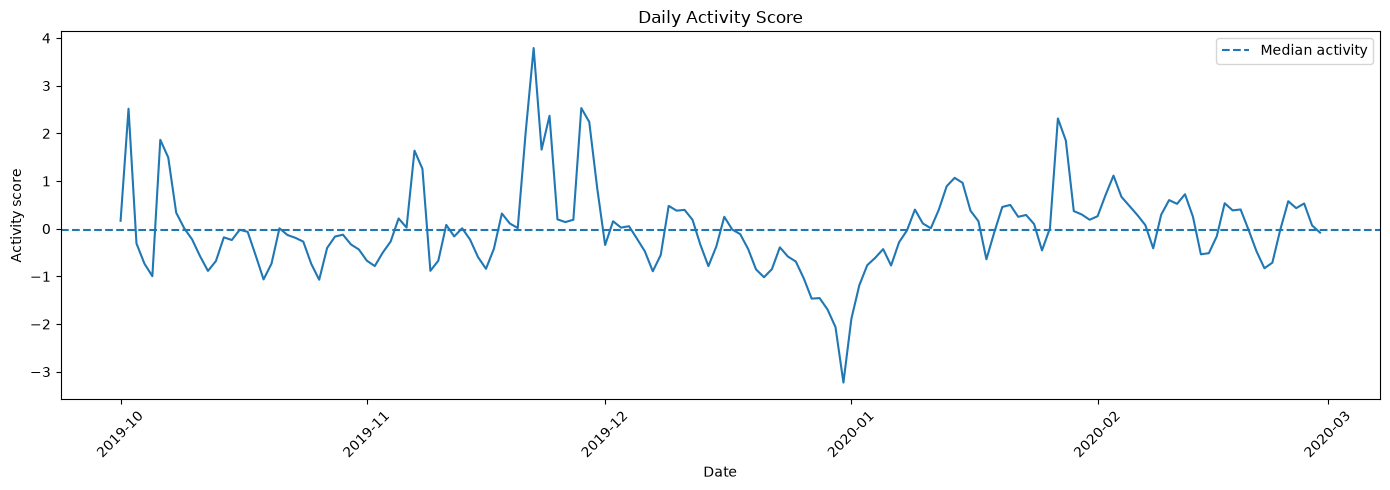

In [ ]:
# ============================================================
# 6.3 VISUALIZE DAILY ACTIVITY
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    daily.index,
    daily["A_d"]
)

plt.axhline(
    M,
    linestyle="--",
    label="Median activity"
)

plt.title(
    "Daily Activity Score"
)

plt.xlabel("Date")
plt.ylabel("Activity score")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 6.4 MERGE EVENT CONTEXT INTO EVENT LOG
# ============================================================

event_context = daily[
    [
        "A_d",
        "Z_robust",
        "event_level"
    ]
].copy()

df_event = (
    df_clean
    .assign(
        date=df_clean["event_time"].dt.floor("D")
    )
    .merge(
        event_context,
        left_on="date",
        right_index=True,
        how="left"
    )
)

display(
    df_event[
        [
            "event_time",
            "event_type",
            "A_d",
            "Z_robust",
            "event_level"
        ]
    ].head()
)

,event_time,event_type,A_d,Z_robust,event_level
0,2020-01-14 16:15:21+00:00,view,1.067204,1.731325,0
1,2020-01-14 16:25:35+00:00,view,1.067204,1.731325,0
2,2020-01-14 16:27:31+00:00,view,1.067204,1.731325,0
3,2019-11-04 15:28:57+00:00,view,-0.268162,-0.391080,0
4,2019-12-28 14:32:56+00:00,view,-1.455470,-2.278165,0


# 7. Stage 3 — Session Construction and Decision Points

Customer events are ordered chronologically.

A new session starts when inactivity exceeds 30 minutes.

The decision point is defined as an observed `cart` event.

For every decision point, only information available before or at the
decision point can be used as model input.

In [ ]:
# ============================================================
# 7.1 BUILD SESSIONS
# ============================================================

df_session = (
    df_event
    .sort_values(
        ["user_id", "event_time"]
    )
    .copy()
)

df_session["gap_minutes"] = (
    df_session
    .groupby("user_id")["event_time"]
    .diff()
    .dt.total_seconds()
    / 60
)

df_session["new_session"] = (
    df_session["gap_minutes"].isna()
    |
    (
        df_session["gap_minutes"]
        > CONFIG["session_gap_minutes"]
    )
)

df_session["session_number"] = (
    df_session
    .groupby("user_id")["new_session"]
    .cumsum()
)

df_session["session_id"] = (
    df_session["user_id"].astype(str)
    + "_"
    + df_session["session_number"].astype(str)
)

print(
    "Sessions:",
    df_session["session_id"].nunique()
)

Sessions: 3320786


In [ ]:
# ============================================================
# 7.2 SESSION SUMMARY
# ============================================================

session_summary = (
    df_session
    .groupby("session_id")
    .size()
    .describe()
)

display(
    session_summary.to_frame("session_length")
)

,session_length
count,3.320786e+06
mean,5.868835e+00
std,1.494003e+01
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,4.000000e+00
max,2.388000e+03


In [ ]:
# ============================================================
# 7.3 DECISION POINTS
# ============================================================

decision_points = (
    df_session[
        df_session["event_type"]
        == CONFIG["decision_event"]
    ]
    .copy()
    .sort_values("event_time")
    .reset_index(drop=True)
)

decision_points["decision_id"] = np.arange(
    len(decision_points)
)

print(
    "Decision points:",
    len(decision_points)
)

display(
    decision_points[
        [
            "decision_id",
            "event_time",
            "user_id",
            "product_id",
            "session_id",
            "price"
        ]
    ].head()
)

Decision points: 5615605


,decision_id,event_time,user_id,product_id,session_id,price
0,0,2019-10-01 00:00:00+00:00,463240011,5773203,463240011_1,2.62
1,1,2019-10-01 00:00:03+00:00,463240011,5773353,463240011_1,2.62
2,2,2019-10-01 00:00:07+00:00,463240011,5723490,463240011_1,2.62
3,3,2019-10-01 00:00:07+00:00,429681830,5881589,429681830_1,13.48
4,4,2019-10-01 00:00:15+00:00,429681830,5881449,429681830_1,0.56


# 8. Stage 4 — Treatment and Outcome Construction

The causal dataset requires:

- X: covariates available at the decision point
- T: observed treatment condition
- Y: observed outcome after the decision

Because the selected real dataset does not provide an explicit promotion
indicator, price variation is examined first.

A treatment proxy is used only if the observed price structure provides
sufficient variation.

In [ ]:
# ============================================================
# 8.1 CHECK PRICE VARIATION
# ============================================================

price_stats = (
    df_session
    .groupby("product_id")["price"]
    .agg(
        min_price="min",
        max_price="max",
        median_price="median",
        n_unique="nunique"
    )
)

price_stats["price_range"] = (
    price_stats["max_price"]
    - price_stats["min_price"]
)

display(
    price_stats
    .sort_values(
        "price_range",
        ascending=False
    )
    .head(20)
)

print(
    "Products with multiple observed prices:",
    (
        price_stats["n_unique"] > 1
    ).sum()
)

,min_price,max_price,median_price,n_unique,price_range
product_id,,,,,
5723944,95.239998,317.459991,317.459991,2,222.220001
5862067,163.429993,297.140015,297.140015,2,133.710022
5898228,153.729996,236.509995,236.509995,2,82.779999
5862074,95.330002,173.330002,173.330002,2,78.000000
5862069,95.330002,173.330002,173.330002,2,78.000000
5646091,108.099998,180.160004,180.160004,3,72.060005
5898227,165.559998,236.509995,236.509995,2,70.949997
5715532,95.709999,159.520004,127.620003,5,63.810005
5862070,89.139999,148.570007,148.570007,2,59.430008


Products with multiple observed prices: 34972


In [ ]:
# ============================================================
# 8.2 PRODUCT REFERENCE PRICE
# ============================================================

df_session = (
    df_session
    .sort_values(
        ["product_id", "event_time"]
    )
    .copy()
)

df_session["reference_price"] = (
    df_session
    .groupby("product_id")["price"]
    .transform(
        lambda x:
        x.expanding()
        .median()
        .shift(1)
    )
)

df_session["reference_price"] = (
    df_session["reference_price"]
    .fillna(
        df_session["price"]
    )
)

In [ ]:
# ============================================================
# 8.3 CONSTRUCT TREATMENT
# ============================================================

dp = decision_points.copy()

# Attach the historical reference price
# to each decision point
reference_prices = (
    df_session[
        [
            "user_id",
            "product_id",
            "event_time",
            "reference_price"
        ]
    ]
    .drop_duplicates(
        [
            "user_id",
            "product_id",
            "event_time"
        ]
    )
)

dp = dp.merge(
    reference_prices,
    on=[
        "user_id",
        "product_id",
        "event_time"
    ],
    how="left"
)

# Treatment proxy:
# a decision is treated if the observed price
# is sufficiently below its historical reference price
dp["discount_rate_proxy"] = (
    1
    - (
        dp["price"]
        / dp["reference_price"]
    )
)

dp["T"] = (
    dp["discount_rate_proxy"]
    >= CONFIG["discount_threshold"]
).astype(int)

print("Treatment distribution:")

display(
    dp["T"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

print(
    "Treatment rate:",
    dp["T"].mean()
)

print(
    "Decision ID available:",
    "decision_id" in dp.columns
)

Treatment distribution:


,count
T,
0,5178388
1,437217


Treatment rate: 0.07785750600336028
Decision ID available: True


In [ ]:
# ============================================================
# 8.4 OUTCOME CONSTRUCTION
# ============================================================

# Get all purchase events
purchases = (
    df_session[
        df_session["event_type"]
        == CONFIG["purchase_event"]
    ][
        [
            "user_id",
            "product_id",
            "event_time"
        ]
    ]
    .sort_values(
        [
            "user_id",
            "product_id",
            "event_time"
        ]
    )
)

# Get decision points
dp_sorted = (
    dp[
        [
            "decision_id",
            "user_id",
            "product_id",
            "event_time"
        ]
    ]
    .sort_values(
        [
            "user_id",
            "product_id",
            "event_time"
        ]
    )
)

# Rename purchase timestamp so that it is not confused
# with the decision timestamp
purchase_times = (
    purchases
    .rename(
        columns={
            "event_time": "purchase_time"
        }
    )
)

# Match each decision point with purchases from
# the same user and same product
check = dp_sorted.merge(
    purchase_times,
    on=[
        "user_id",
        "product_id"
    ],
    how="left"
)

# Calculate time between decision and purchase
check["delta_minutes"] = (
    (
        check["purchase_time"]
        - check["event_time"]
    )
    .dt.total_seconds()
    / 60
)

# Outcome Y = 1 if purchase happens
# within the defined outcome window
check["Y"] = (
    (check["delta_minutes"] > 0)
    &
    (
        check["delta_minutes"]
        <= CONFIG["outcome_window_minutes"]
    )
).astype(int)

# If multiple purchases are matched to one decision,
# keep Y = 1 if at least one valid purchase exists
outcome_by_decision = (
    check
    .groupby("decision_id")["Y"]
    .max()
)

# Attach outcome back to decision-point dataframe
dp["Y"] = (
    dp["decision_id"]
    .map(outcome_by_decision)
    .fillna(0)
    .astype(int)
)

print("Outcome distribution:")

display(
    dp["Y"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

Outcome distribution:


,count
Y,
0,4646185
1,969420


# 9. Stage 5 — Feature Construction

The covariates contain only information available at or before the decision
point.

Feature groups include:

1. behavioral features
2. temporal features
3. macro-event features
4. product features
5. customer-level features

Post-treatment and post-outcome information is excluded.

In [ ]:
# ============================================================
# 9.1 STATIC FEATURES
# ============================================================

dp["hour"] = (
    dp["event_time"]
    .dt.hour
)

dp["day_of_week"] = (
    dp["event_time"]
    .dt.dayofweek
)

dp["day_of_month"] = (
    dp["event_time"]
    .dt.day
)

dp["month"] = (
    dp["event_time"]
    .dt.month
)

# Product-level historical price
dp["price_deviation"] = (
    dp["price"]
    - dp["reference_price"]
) / (
    dp["reference_price"] + 1e-8
)

In [ ]:
# ============================================================
# 9.2 PRE-DECISION BEHAVIOR FEATURES
# ============================================================

# Work on a lightweight copy containing only columns needed
# for behavioral feature construction.

behavior_base = (
    df_session[
        [
            "session_id",
            "event_time",
            "event_type",
            "product_id",
            "category_id"
        ]
    ]
    .sort_values(
        [
            "session_id",
            "event_time"
        ]
    )
    .copy()
)

# ------------------------------------------------------------
# 1. Event-level indicators
# ------------------------------------------------------------

behavior_base["is_view"] = (
    behavior_base["event_type"] == "view"
).astype("int8")

behavior_base["is_cart"] = (
    behavior_base["event_type"] == "cart"
).astype("int8")

behavior_base["is_remove"] = (
    behavior_base["event_type"] == "remove_from_cart"
).astype("int8")

behavior_base["is_purchase"] = (
    behavior_base["event_type"] == "purchase"
).astype("int8")

# ------------------------------------------------------------
# 2. Number of events BEFORE current event
# ------------------------------------------------------------

behavior_base["session_events_before"] = (
    behavior_base
    .groupby("session_id")
    .cumcount()
)

# ------------------------------------------------------------
# 3. Cumulative behavioral counts BEFORE current event
# ------------------------------------------------------------

for source_col, output_col in [
    ("is_view", "views_before"),
    ("is_cart", "cart_before"),
    ("is_remove", "remove_before"),
    ("is_purchase", "purchase_before"),
]:

    behavior_base[output_col] = (
        behavior_base
        .groupby("session_id")[source_col]
        .cumsum()
        .sub(behavior_base[source_col])
    )

# ------------------------------------------------------------
# 4. Unique products BEFORE current event
# ------------------------------------------------------------

first_product_in_session = (
    ~behavior_base
    .duplicated(
        [
            "session_id",
            "product_id"
        ],
        keep="first"
    )
)

behavior_base["_new_product"] = (
    first_product_in_session.astype("int8")
)

behavior_base["unique_products_before"] = (
    behavior_base
    .groupby("session_id")["_new_product"]
    .cumsum()
    .sub(behavior_base["_new_product"])
)

# ------------------------------------------------------------
# 5. Unique categories BEFORE current event
# ------------------------------------------------------------

first_category_in_session = (
    ~behavior_base
    .duplicated(
        [
            "session_id",
            "category_id"
        ],
        keep="first"
    )
)

behavior_base["_new_category"] = (
    first_category_in_session.astype("int8")
)

behavior_base["unique_categories_before"] = (
    behavior_base
    .groupby("session_id")["_new_category"]
    .cumsum()
    .sub(behavior_base["_new_category"])
)

# ------------------------------------------------------------
# 6. Keep only decision-point rows
# ------------------------------------------------------------

behavior_features = (
    behavior_base[
        behavior_base["event_type"]
        == CONFIG["decision_event"]
    ][
        [
            "session_events_before",
            "views_before",
            "cart_before",
            "remove_before",
            "purchase_before",
            "unique_products_before",
            "unique_categories_before"
        ]
    ]
    .copy()
)

# Use the same row order as decision_points / dp
behavior_features["decision_id"] = (
    dp["decision_id"].to_numpy()
)

# Put decision_id first
behavior_features = behavior_features[
    [
        "decision_id",
        "session_events_before",
        "views_before",
        "cart_before",
        "remove_before",
        "purchase_before",
        "unique_products_before",
        "unique_categories_before"
    ]
]

# ------------------------------------------------------------
# 7. Merge features into decision-point dataframe
# ------------------------------------------------------------

dp = dp.merge(
    behavior_features,
    on="decision_id",
    how="left"
)

# ------------------------------------------------------------
# 8. Check result
# ------------------------------------------------------------

print("Behavior features created successfully.")

print(
    "Number of decision points:",
    len(dp)
)

print(
    "Behavior feature rows:",
    len(behavior_features)
)

display(
    dp[
        [
            "decision_id",
            "session_events_before",
            "views_before",
            "cart_before",
            "remove_before",
            "purchase_before",
            "unique_products_before",
            "unique_categories_before"
        ]
    ].head(10)
)

Behavior features created successfully.
Number of decision points: 5615605
Behavior feature rows: 5615605


,decision_id,session_events_before,views_before,cart_before,remove_before,purchase_before,unique_products_before,unique_categories_before
0,0,0,0,0,0,0,0,0
1,1,1,0,1,0,0,1,1
2,2,0,0,0,0,0,0,0
3,3,1,0,1,0,0,1,1
4,4,2,0,2,0,0,1,1
5,5,3,0,3,0,0,1,1
6,6,4,0,4,0,0,1,1
7,7,6,0,5,1,0,1,1
8,8,7,0,6,1,0,2,1
9,9,8,0,7,1,0,2,1


In [ ]:
# ============================================================
# 9.3 CUSTOMER HISTORY
# ============================================================

df_before = df_session[
    [
        "user_id",
        "event_time",
        "event_type"
    ]
].copy()

user_stats = (
    df_before
    .groupby("user_id")
    .agg(
        total_events=("event_type", "size"),
        total_views=(
            "event_type",
            lambda x:
            (x == "view").sum()
        ),
        total_carts=(
            "event_type",
            lambda x:
            (x == "cart").sum()
        ),
        total_purchases=(
            "event_type",
            lambda x:
            (x == "purchase").sum()
        )
    )
    .reset_index()
)

dp = dp.merge(
    user_stats,
    on="user_id",
    how="left"
)

In [ ]:
# ============================================================
# 9.4 FINAL STATIC FEATURE MATRIX
# ============================================================

feature_cols = [

    "price",
    "reference_price",
    "price_deviation",

    "event_level",
    "A_d",
    "Z_robust",

    "hour",
    "day_of_week",
    "day_of_month",
    "month",

    "session_events_before",
    "views_before",
    "cart_before",
    "remove_before",
    "purchase_before",

    "unique_products_before",
    "unique_categories_before",

    "total_events",
    "total_views",
    "total_carts",
    "total_purchases"
]

feature_cols = [
    c for c in feature_cols
    if c in dp.columns
]

X_static = (
    dp[feature_cols]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .fillna(0)
    .astype(float)
)

print(
    "Static features:",
    X_static.shape
)

display(
    X_static.head()
)

Static features: (5615605, 17)


,price,reference_price,price_deviation,event_level,A_d,Z_robust,hour,day_of_week,day_of_month,month,session_events_before,views_before,cart_before,remove_before,purchase_before,unique_products_before,unique_categories_before
0,2.62,2.62,0.0,0.0,0.165802,0.298653,0.0,1.0,1.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.62,2.62,0.0,0.0,0.165802,0.298653,0.0,1.0,1.0,10.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0
2,2.62,2.62,0.0,0.0,0.165802,0.298653,0.0,1.0,1.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,13.48,13.48,0.0,0.0,0.165802,0.298653,0.0,1.0,1.0,10.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0
4,0.56,0.56,0.0,0.0,0.165802,0.298653,0.0,1.0,1.0,10.0,2.0,0.0,2.0,0.0,0.0,1.0,1.0


# 10. Stage 6 — Behavioral Sequence Representation

Each decision point is represented by the sequence of events occurring
before the decision within the same session.

The sequence is padded/truncated to MAX_LEN.

The GRU produces a latent behavioral representation that is later combined
with static contextual variables for predictive and uplift modeling.

In [ ]:
# ============================================================
# 10.1 EVENT VOCABULARY
# ============================================================

EVENT_VOCAB = {
    "view": 1,
    "cart": 2,
    "remove_from_cart": 3,
    "purchase": 4
}

MAX_LEN = CONFIG[
    "max_sequence_length"
]

def encode_sequence(events):

    encoded = [
        EVENT_VOCAB.get(
            event,
            0
        )
        for event in events
    ]

    encoded = encoded[
        -MAX_LEN:
    ]

    padded = (
        [0] * (
            MAX_LEN
            - len(encoded)
        )
        + encoded
    )

    return padded

In [ ]:
# ============================================================
# 10.2 BUILD PRE-DECISION SEQUENCES
# ============================================================

from collections import defaultdict

# ------------------------------------------------------------
# 1. Prepare decision lookup
# ------------------------------------------------------------

decision_lookup = defaultdict(list)

for row in dp[
    [
        "decision_id",
        "session_id",
        "event_time"
    ]
].itertuples(index=False):

    decision_lookup[
        (row.session_id, row.event_time)
    ].append(row.decision_id)

# ------------------------------------------------------------
# 2. Sort events ONCE
# ------------------------------------------------------------

session_events = (
    df_session[
        [
            "session_id",
            "event_time",
            "event_type"
        ]
    ]
    .sort_values(
        [
            "session_id",
            "event_time"
        ],
        kind="mergesort"
    )
)

# ------------------------------------------------------------
# 3. Process events sequentially
# ------------------------------------------------------------

sequence_by_decision = {}

current_session = None
current_time = None

history_events = []
current_timestamp_events = []

for row in session_events.itertuples(index=False):

    session_id = row.session_id
    event_time = row.event_time
    event_type = row.event_type

    # --------------------------------------------------------
    # New session
    # --------------------------------------------------------

    if session_id != current_session:

        # Reset history for new session
        current_session = session_id
        current_time = event_time

        history_events = []
        current_timestamp_events = []

    # --------------------------------------------------------
    # New timestamp
    # --------------------------------------------------------

    elif event_time != current_time:

        # Current timestamp is finished.
        # Add ALL events from that timestamp to history.
        history_events.extend(
            current_timestamp_events
        )

        current_timestamp_events = []
        current_time = event_time

    # --------------------------------------------------------
    # Decision point
    # --------------------------------------------------------

    key = (
        session_id,
        event_time
    )

    if key in decision_lookup:

        encoded = encode_sequence(
            history_events
        )

        for decision_id in decision_lookup[key]:

            sequence_by_decision[
                decision_id
            ] = encoded

    # --------------------------------------------------------
    # Store current event
    #
    # IMPORTANT:
    # Do NOT add it to history yet.
    #
    # This guarantees:
    # event_time < decision_time
    # --------------------------------------------------------

    current_timestamp_events.append(
        event_type
    )

# ------------------------------------------------------------
# 4. Restore exact decision order
# ------------------------------------------------------------

empty_sequence = encode_sequence([])

sequence_data = [
    sequence_by_decision.get(
        decision_id,
        empty_sequence
    )
    for decision_id in dp["decision_id"]
]

# ------------------------------------------------------------
# 5. Convert to NumPy
# ------------------------------------------------------------

X_seq = np.asarray(
    sequence_data,
    dtype=np.int32
)

print(
    "Sequence shape:",
    X_seq.shape
)

print(
    "Number of sequences:",
    len(X_seq)
)

print(
    "Sequences generated:",
    len(sequence_by_decision)
)

Sequence shape: (5615605, 4)
Number of sequences: 5615605
Sequences generated: 5615605


In [ ]:
# ============================================================
# 10.3 GRU BEHAVIOR ENCODER
# ============================================================

if HAS_TF:

    sequence_input = layers.Input(
        shape=(MAX_LEN,),
        name="event_sequence"
    )

    embedding = layers.Embedding(
        input_dim=5,
        output_dim=CONFIG[
            "embedding_dim"
        ],
        mask_zero=True,
        name="event_embedding"
    )(sequence_input)

    gru_output = layers.GRU(
        CONFIG["gru_units"],
        name="gru_encoder"
    )(embedding)

    gru_encoder = Model(
        sequence_input,
        gru_output
    )

    gru_encoder.summary()

else:
    print(
        "TensorFlow unavailable."
    )

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ event_sequence      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ event_embedding     │ (None, 4, 8)      │         40 │ event_sequence[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 4)         │          0 │ event_sequence[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_encoder (GRU)   │ (None, 16)        │      1,248 │ event_embedding[… │
│                     │                   │            │ not_equal[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,288 (5.03 KB)

 Trainable params: 1,288 (5.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# 10.4 EXTRACT GRU REPRESENTATION
# ============================================================

if HAS_TF:

    H = gru_encoder.predict(
        X_seq,
        verbose=0
    )

else:

    H = np.zeros(
        (
            len(X_seq),
            CONFIG["gru_units"]
        )
    )

print(
    "GRU representation:",
    H.shape
)

GRU representation: (5615605, 16)


In [ ]:
# ============================================================
# 10.5 COMBINE BEHAVIOR + STATIC FEATURES
# ============================================================

scaler = StandardScaler()

X_static_scaled = (
    scaler.fit_transform(
        X_static
    )
)

X = np.hstack([
    H,
    X_static_scaled
])

T = dp["T"].values.astype(int)

Y = dp["Y"].values.astype(int)

print("X:", X.shape)
print("T:", T.shape)
print("Y:", Y.shape)

X: (5615605, 33)
T: (5615605,)
Y: (5615605,)


## 10.6 Temporal Train / Validation / Test Split

Decision points are ordered chronologically.

The earliest observations are used for training, the middle period for
validation, and the latest observations are reserved for final testing.

The test set is not used for model selection.

In [ ]:
# ============================================================
# 10.6 TEMPORAL SPLIT
# ============================================================

order = np.argsort(
    dp["event_time"].values
)

X_ordered = X[order]
T_ordered = T[order]
Y_ordered = Y[order]

dp_ordered = dp.iloc[
    order
].reset_index(drop=True)

n = len(dp_ordered)

test_start = int(
    n
    * (
        1
        - CONFIG["test_ratio"]
    )
)

val_start = int(
    test_start
    * (
        1
        - CONFIG[
            "validation_ratio"
        ]
    )
)

X_train = X_ordered[
    :val_start
]

T_train = T_ordered[
    :val_start
]

Y_train = Y_ordered[
    :val_start
]

X_val = X_ordered[
    val_start:test_start
]

T_val = T_ordered[
    val_start:test_start
]

Y_val = Y_ordered[
    val_start:test_start
]

X_test = X_ordered[
    test_start:
]

T_test = T_ordered[
    test_start:
]

Y_test = Y_ordered[
    test_start:
]

print(
    "Train:",
    len(X_train)
)

print(
    "Validation:",
    len(X_val)
)

print(
    "Test:",
    len(X_test)
)

Train: 3593987
Validation: 898497
Test: 1123121


In [ ]:
# ============================================================
# 10.7 BASELINE — LOGISTIC REGRESSION
# ============================================================

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED
)

lr.fit(
    X_train,
    Y_train
)

val_lr = lr.predict_proba(
    X_val
)[:, 1]

test_lr = lr.predict_proba(
    X_test
)[:, 1]

print(
    "LR validation AUC:",
    roc_auc_score(
        Y_val,
        val_lr
    )
)

print(
    "LR test AUC:",
    roc_auc_score(
        Y_test,
        test_lr
    )
)

LR validation AUC: 0.5549170000988456
LR test AUC: 0.5604378586403744


In [ ]:
# ============================================================
# 10.8 BASELINE — LIGHTGBM
# ============================================================

if HAS_LGB:

    lgb_model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.03,
        num_leaves=31,
        class_weight="balanced",
        random_state=SEED,
        verbose=-1
    )

    lgb_model.fit(
        X_train,
        Y_train
    )

    val_lgb = (
        lgb_model
        .predict_proba(X_val)[:, 1]
    )

    test_lgb = (
        lgb_model
        .predict_proba(X_test)[:, 1]
    )

    print(
        "LightGBM validation AUC:",
        roc_auc_score(
            Y_val,
            val_lgb
        )
    )

    print(
        "LightGBM test AUC:",
        roc_auc_score(
            Y_test,
            test_lgb
        )
    )

LightGBM validation AUC: 0.6033211384966045
LightGBM test AUC: 0.6086686222046287


In [ ]:
# ============================================================
# 10.9 SIMPLE GRU PREDICTIVE MODEL
# ============================================================

if HAS_TF:

    seq_input = layers.Input(
        shape=(MAX_LEN,)
    )

    emb = layers.Embedding(
        input_dim=5,
        output_dim=CONFIG["embedding_dim"],
        mask_zero=True
    )(seq_input)

    h = layers.GRU(
        CONFIG["gru_units"]
    )(emb)

    output = layers.Dense(
        1,
        activation="sigmoid"
    )(h)

    gru_predictor = Model(
        seq_input,
        output
    )

    gru_predictor.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["AUC"]
    )

    train_indices = order[
        :val_start
    ]

    val_indices = order[
        val_start:test_start
    ]

    gru_predictor.fit(
        X_seq[train_indices],
        Y_train,
        validation_data=(
            X_seq[val_indices],
            Y_val
        ),
        epochs=10,
        batch_size=64,
        verbose=1
    )

Epoch 1/10
56157/56157 ━━━━━━━━━━━━━━━━━━━━ 83s 1ms/step - AUC: 0.5782 - loss: 0.4553 - val_AUC: 0.5626 - val_loss: 0.4696
Epoch 2/10
56157/56157 ━━━━━━━━━━━━━━━━━━━━ 76s 1ms/step - AUC: 0.5837 - loss: 0.4537 - val_AUC: 0.5627 - val_loss: 0.4695
Epoch 3/10
56157/56157 ━━━━━━━━━━━━━━━━━━━━ 77s 1ms/step - AUC: 0.5841 - loss: 0.4537 - val_AUC: 0.5627 - val_loss: 0.4695
Epoch 4/10
56157/56157 ━━━━━━━━━━━━━━━━━━━━ 77s 1ms/step - AUC: 0.5842 - loss: 0.4537 - val_AUC: 0.5627 - val_loss: 0.4695
Epoch 5/10
56157/56157 ━━━━━━━━━━━━━━━━━━━━ 78s 1ms/step - AUC: 0.5843 - loss: 0.4536 - val_AUC: 0.5628 - val_loss: 0.4694
Epoch 6/10
56157/56157 ━━━━━━━━━━━━━━━━━━━━ 78s 1ms/step - AUC: 0.5844 - loss: 0.4536 - val_AUC: 0.5628 - val_loss: 0.4694
Epoch 7/10
56157/56157 ━━━━━━━━━━━━━━━━━━━━ 78s 1ms/step - AUC: 0.5844 - loss: 0.4536 - val_AUC: 0.5630 - val_loss: 0.4694
Epoch 8/10
56157/56157 ━━━━━━━━━━━━━━━━━━━━ 77s 1ms/step - AUC: 0.5844 - loss: 0.4536 - val_AUC: 0.5630 - val_loss: 0.4694
Epoch 9/10
56157

# 11. Stage 7 — Uplift / CATE Estimation

The central target is the conditional average treatment effect:

$$
\tau(X) = E[Y(1) - Y(0) \mid X]
$$

Two outcome models estimate:

$$
\mu_1(X) = P(Y=1 \mid T=1, X)
$$

and

$$
\mu_0(X) = P(Y=1 \mid T=0, X)
$$

The estimated uplift is:

$$
\hat{\tau}(X) = \hat{\mu}_1(X) - \hat{\mu}_0(X)
$$

In [ ]:
# ============================================================
# 11.1 TREATMENT OVERLAP
# ============================================================

print("TRAIN TREATMENT DISTRIBUTION")

display(
    pd.Series(T_train)
    .value_counts()
    .sort_index()
    .to_frame("count")
)

print(
    "Treatment rate:",
    T_train.mean()
)

if (
    T_train.mean() < 0.05
    or T_train.mean() > 0.95
):

    print(
        "WARNING: weak treatment overlap."
    )

TRAIN TREATMENT DISTRIBUTION


,count
0,3233352
1,360635


Treatment rate: 0.10034399122756983


In [ ]:
# ============================================================
# 11.2 CONTROL MODEL μ0
# ============================================================

control_mask = (
    T_train == 0
)

control_model = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

control_model.fit(
    X_train[control_mask],
    Y_train[control_mask]
)

print("Control model μ0 trained successfully.")

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


Control model μ0 trained successfully.


In [ ]:
# ============================================================
# 11.3 TREATMENT MODEL μ1
# ============================================================

treatment_mask = (
    T_train == 1
)

treatment_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=SEED
)

treatment_model.fit(
    X_train[treatment_mask],
    Y_train[treatment_mask]
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1

In [ ]:
# ============================================================
# 11.4 ESTIMATE μ0, μ1 AND τ
# ============================================================

mu0_val = (
    control_model
    .predict_proba(X_val)[:, 1]
)

mu1_val = (
    treatment_model
    .predict_proba(X_val)[:, 1]
)

tau_val = (
    mu1_val
    - mu0_val
)

mu0_test = (
    control_model
    .predict_proba(X_test)[:, 1]
)

mu1_test = (
    treatment_model
    .predict_proba(X_test)[:, 1]
)

tau_test = (
    mu1_test
    - mu0_test
)

print("Validation uplift:")
display(
    pd.Series(
        tau_val
    ).describe()
)

print("\nTest uplift:")
display(
    pd.Series(
        tau_test
    ).describe()
)

Validation uplift:


count    898497.000000
mean         -0.054879
std           0.078138
min          -0.480027
25%          -0.105721
50%          -0.054642
75%          -0.003822
max           0.375507
dtype: float64


Test uplift:


count    1.123121e+06
mean    -6.277155e-02
std      7.949544e-02
min     -5.304525e-01
25%     -1.140542e-01
50%     -6.205199e-02
75%     -1.094397e-02
max      3.447914e-01
dtype: float64

In [ ]:
# ============================================================
# 11.5 UPLIFT CURVE
# ============================================================

def calculate_uplift_curve(
    y,
    treatment,
    score,
    n_bins=20
):

    data = pd.DataFrame({
        "y": y,
        "treatment": treatment,
        "score": score
    })

    data = data.sort_values(
        "score",
        ascending=False
    ).reset_index(
        drop=True
    )

    results = []

    for fraction in np.linspace(
        0.05,
        1.0,
        n_bins
    ):

        n = max(
            1,
            int(
                len(data)
                * fraction
            )
        )

        subset = data.iloc[:n]

        treated = subset[
            subset["treatment"] == 1
        ]

        control = subset[
            subset["treatment"] == 0
        ]

        if (
            len(treated) == 0
            or len(control) == 0
        ):
            continue

        uplift = (
            treated["y"].mean()
            -
            control["y"].mean()
        )

        results.append({
            "fraction": fraction,
            "uplift": uplift
        })

    return pd.DataFrame(results)

In [ ]:
# ============================================================
# 11.6 VALIDATION UPLIFT CURVE
# ============================================================

uplift_val = calculate_uplift_curve(
    Y_val,
    T_val,
    tau_val
)

display(
    uplift_val
)

,fraction,uplift
0,0.05,-0.026129
1,0.10,-0.034134
2,0.15,-0.025898
3,0.20,-0.032666
4,0.25,-0.034134
5,0.30,-0.032441
6,0.35,-0.034475
7,0.40,-0.037253
8,0.45,-0.038862
9,0.50,-0.040308


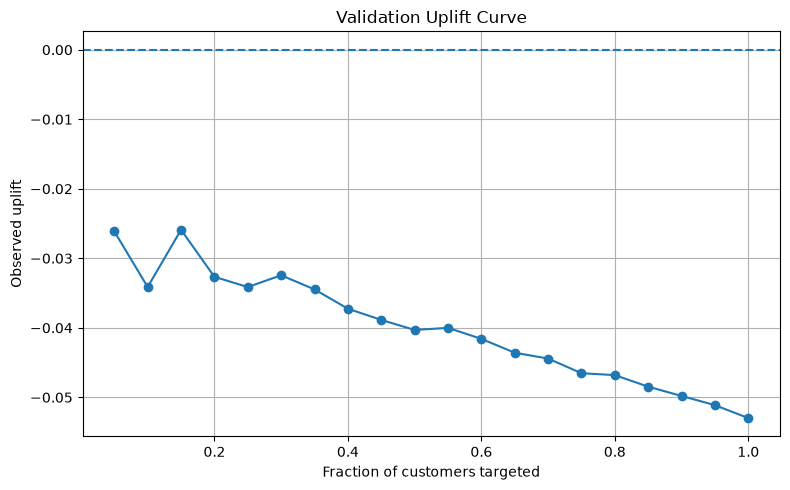

In [ ]:
# ============================================================
# 11.7 PLOT UPLIFT CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    uplift_val["fraction"],
    uplift_val["uplift"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Fraction of customers targeted"
)

plt.ylabel(
    "Observed uplift"
)

plt.title(
    "Validation Uplift Curve"
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# 11.8 FINAL TEST UPLIFT
# ============================================================

uplift_test = calculate_uplift_curve(
    Y_test,
    T_test,
    tau_test
)

display(
    uplift_test
)

,fraction,uplift
0,0.05,-0.006997
1,0.10,0.006159
2,0.15,0.001091
3,0.20,0.001506
4,0.25,-0.000083
5,0.30,-0.002790
6,0.35,-0.005169
7,0.40,-0.005250
8,0.45,-0.005517
9,0.50,-0.006827


# 12. Promotion Policy

The estimated treatment effect is translated into a promotion decision.

A customer is considered for promotion only when the estimated incremental
effect is sufficiently positive.

The no-promotion action remains available as the baseline decision.

In [ ]:
# ============================================================
# 12.1 POLICY DATASET
# ============================================================

policy = pd.DataFrame({

    "mu0_hat": mu0_test,

    "mu1_hat": mu1_test,

    "tau_hat": tau_test,

    "actual_treatment": T_test,

    "actual_outcome": Y_test
})

policy["recommendation"] = np.where(
    policy["tau_hat"]
    >= CONFIG["tau_threshold"],
    "PROMOTE",
    "DO NOT PROMOTE"
)

display(
    policy.head(20)
)

,mu0_hat,mu1_hat,tau_hat,actual_treatment,actual_outcome,recommendation
0,0.374662,0.375488,0.000827,0,0,DO NOT PROMOTE
1,0.421158,0.367885,-0.053272,0,0,DO NOT PROMOTE
2,0.359672,0.312690,-0.046982,0,1,DO NOT PROMOTE
3,0.364479,0.326240,-0.038239,0,1,DO NOT PROMOTE
4,0.405906,0.337867,-0.068039,0,1,DO NOT PROMOTE
5,0.349144,0.315090,-0.034053,0,1,DO NOT PROMOTE
6,0.474070,0.547426,0.073356,0,0,PROMOTE
7,0.326905,0.342642,0.015737,0,1,DO NOT PROMOTE
8,0.319152,0.321397,0.002245,0,0,DO NOT PROMOTE
9,0.316609,0.315199,-0.001410,0,0,DO NOT PROMOTE


In [ ]:
# ============================================================
# 12.2 POLICY DISTRIBUTION
# ============================================================

display(
    policy["recommendation"]
    .value_counts()
    .to_frame("count")
)

,count
recommendation,
DO NOT PROMOTE,1041383
PROMOTE,81738


In [ ]:
# ============================================================
# 12.3 POLICY VALUE SENSITIVITY
# ============================================================

promotion_costs = [
    0.00,
    0.02,
    0.05,
    0.10
]

policy_value_results = []

for cost in promotion_costs:

    expected_incremental_value = (
        policy["tau_hat"]
        - cost
    )

    promote = (
        expected_incremental_value
        > 0
    )

    policy_value_results.append({

        "promotion_cost":
            cost,

        "promotion_rate":
            promote.mean(),

        "mean_expected_incremental_value":
            expected_incremental_value.mean()
    })

policy_value_df = pd.DataFrame(
    policy_value_results
)

display(
    policy_value_df
)

,promotion_cost,promotion_rate,mean_expected_incremental_value
0,0.00,0.206845,-0.062772
1,0.02,0.140607,-0.082772
2,0.05,0.072778,-0.112772
3,0.10,0.020531,-0.162772


# 13. Explainability

SHAP is used to examine which observable model inputs are associated with
the treatment-effect estimation.

Latent GRU dimensions are treated as representation variables rather than
direct business rules.

In [ ]:
# ============================================================
# 13.1 SHAP
# ============================================================

if HAS_SHAP:

    explainer = shap.TreeExplainer(
        treatment_model
    )

    sample_n = min(
        500,
        len(X_test)
    )

    shap_values = (
        explainer
        .shap_values(
            X_test[:sample_n]
        )
    )

    shap.summary_plot(
        shap_values,
        X_test[:sample_n],
        show=True
    )

else:

    print(
        "SHAP unavailable."
    )

In [ ]:
# ============================================================
# 14. MODEL COMPARISON
# ============================================================

model_results = []

model_results.append({
    "model": "Logistic Regression",
    "validation_auc":
        roc_auc_score(
            Y_val,
            val_lr
        ),
    "test_auc":
        roc_auc_score(
            Y_test,
            test_lr
        )
})

if HAS_LGB:

    model_results.append({
        "model": "LightGBM",
        "validation_auc":
            roc_auc_score(
                Y_val,
                val_lgb
            ),
        "test_auc":
            roc_auc_score(
                Y_test,
                test_lgb
            )
    })

model_comparison = pd.DataFrame(
    model_results
)

display(
    model_comparison
)

In [ ]:
# ============================================================
# 15. FINAL UPLIFT RESULTS
# ============================================================

final_results = policy.copy()

final_results["absolute_uplift"] = (
    final_results["tau_hat"].abs()
)

final_results = (
    final_results
    .sort_values(
        "tau_hat",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    final_results.head(20)
)

In [ ]:
# ============================================================
# 15.1 EXPORT RESULTS
# ============================================================

final_results.to_csv(
    "final_uplift_results.csv",
    index=False
)

daily.to_csv(
    "daily_event_discovery.csv"
)

model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print(
    "Results exported successfully."
)

# 16. Conclusion

The revised pipeline moves from purchase propensity prediction to
incremental promotion-effect estimation.

The analysis proceeds through:

1. real-data preprocessing
2. data-driven temporal event discovery
3. session and decision-point construction
4. treatment and outcome definition
5. behavioral representation learning
6. predictive benchmarking
7. uplift/CATE estimation
8. temporal validation
9. explainability
10. promotion policy generation

The main analytical output is the estimated treatment effect:

\[
\hat{\tau}(X)
=
\hat{\mu}_1(X)
-
\hat{\mu}_0(X)
\]

A positive value indicates that promotion is estimated to increase the
probability of the selected outcome relative to the no-promotion condition.

Therefore, the final promotion decision is based on incremental value
rather than purchase propensity alone.